# 🏥 Tech Challenge – Fase 04 | POSTECH Data Analytics
## Pipeline de ML Corrigida — Diagnóstico e Solução do Overfitting

---

### ⚠️ Problemas identificados no notebook original

| # | Problema | Impacto |
|---|---|---|
| 1 | **Data leakage** — linhas sintéticas (SMOTE) misturadas no split treino/teste | Acurácia inflada: modelo via dados quase idênticos no teste |
| 2 | **Test set contaminado** — 74,8% dos dados são sintéticos gerados *após* coleta | Métricas não representam performance no mundo real |
| 3 | **Dataset altamente separável por IMC** — BMI quase não tem sobreposição entre classes | Qualquer modelo baseado em árvore atinge ~95–100% com essas features |
| 4 | **Test set pequeno** — apenas 107 linhas originais disponíveis para teste | Alta variância nas métricas finais |

### ✅ Correções aplicadas
1. Separação de linhas **originais vs sintéticas** antes de qualquer split
2. Split feito **somente sobre originais** — sintéticas vão **apenas para o treino**
3. Análise de separabilidade do dataset documentada
4. Uso de **cross-validation estratificada** para estimativa robusta


In [1]:
# =========================================================
# 1. IMPORTAÇÕES
# =========================================================
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import xgboost as xgb
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)
print("✅ Importações concluídas")


✅ Importações concluídas


## 2. Carregamento dos Dados

In [2]:
# =========================================================
# 2.1 Carregamento
# =========================================================
CSV_PATH = 'Obesity.csv'
if not os.path.exists(CSV_PATH):
    CSV_PATH = '/mnt/user-data/uploads/Obesity.csv'

df = pd.read_csv(CSV_PATH)
print(f"Shape total: {df.shape}")
df.head()


Shape total: (2111, 17)


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 3. Diagnóstico do Dataset

### 3.1 Origem dos dados
O dataset `Obesity.csv` é parcialmente **sintético**: foi originalmente coletado com ~500 respostas reais,
e depois expandido via **SMOTE** (Synthetic Minority Oversampling Technique) para ~2.100 linhas.

A evidência está nas colunas ordinais (`FCVC`, `NCP`, `CH2O`, `FAF`, `TUE`):
- **Linhas originais**: valores inteiros (1, 2, 3...)
- **Linhas sintéticas**: valores com casas decimais (1.541, 2.704...)

> **Por que isso causa overfitting aparente?**  
> Linhas sintéticas são interpolações matemáticas de linhas reais. Se uma linha sintética cai no conjunto
> de teste, o modelo terá visto seu "pai" no treino — resultando em métricas irrealisticamente altas.


Linhas originais  (inteiras) :  531  (25.2%)
Linhas sintéticas (decimais) : 1580  (74.8%)
Total                        : 2111


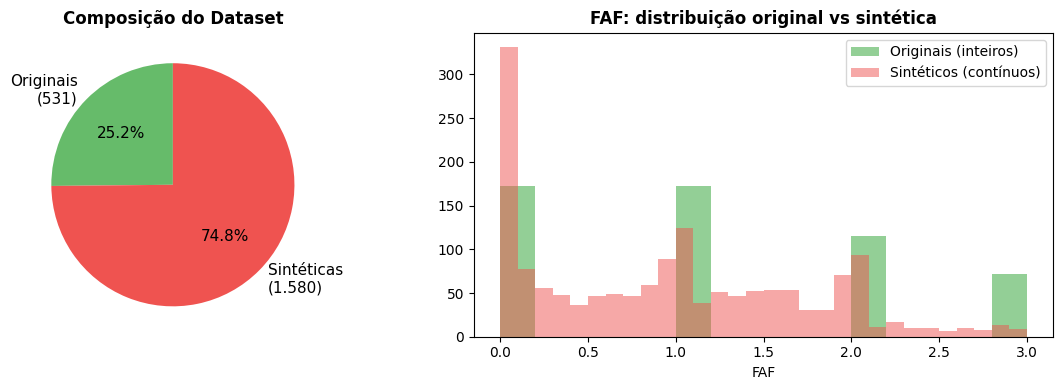

In [3]:
# =========================================================
# 3.1 Identificação de linhas sintéticas vs originais
# =========================================================
ORDINAL_COLS = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

synthetic_mask = pd.Series([False] * len(df))
for col in ORDINAL_COLS:
    synthetic_mask = synthetic_mask | (df[col] % 1 != 0)

df_orig = df[~synthetic_mask].reset_index(drop=True)
df_synt = df[synthetic_mask].reset_index(drop=True)

print(f"Linhas originais  (inteiras) : {len(df_orig):4d}  ({len(df_orig)/len(df)*100:.1f}%)")
print(f"Linhas sintéticas (decimais) : {len(df_synt):4d}  ({len(df_synt)/len(df)*100:.1f}%)")
print(f"Total                        : {len(df):4d}")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie
axes[0].pie([len(df_orig), len(df_synt)],
            labels=['Originais\n(531)', 'Sintéticas\n(1.580)'],
            colors=['#66bb6a', '#ef5350'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title('Composição do Dataset', fontweight='bold')

# Distribuição de FCVC como evidência
axes[1].hist(df_orig['FAF'], bins=15, alpha=0.7, color='#66bb6a', label='Originais (inteiros)')
axes[1].hist(df_synt['FAF'], bins=30, alpha=0.5, color='#ef5350', label='Sintéticos (contínuos)')
axes[1].set_title('FAF: distribuição original vs sintética', fontweight='bold')
axes[1].set_xlabel('FAF')
axes[1].legend()

plt.tight_layout()
plt.show()


IMC por classe (dados originais):
                       min    max   mean
Obesity                                 
Insufficient_Weight  13.29  18.42  17.45
Normal_Weight        18.49  24.91  22.01
Overweight_Level_I   25.08  26.89  26.08
Overweight_Level_II  25.71  29.94  28.31
Obesity_Type_I       30.11  35.01  32.14
Obesity_Type_II      35.00  39.26  36.94
Obesity_Type_III     40.64  49.47  44.01

Sobreposição de IMC entre classes adjacentes:
  ✅ Separáveis | Insufficient_Weight ↔ Normal_Weight: -0.07
  ✅ Separáveis | Normal_Weight ↔ Overweight_Level_I: -0.17
  ⚠️  SOBREPOSIÇÃO | Overweight_Level_I ↔ Overweight_Level_II: 1.18
  ✅ Separáveis | Overweight_Level_II ↔ Obesity_Type_I: -0.17
  ⚠️  SOBREPOSIÇÃO | Obesity_Type_I ↔ Obesity_Type_II: 0.01
  ✅ Separáveis | Obesity_Type_II ↔ Obesity_Type_III: -1.38


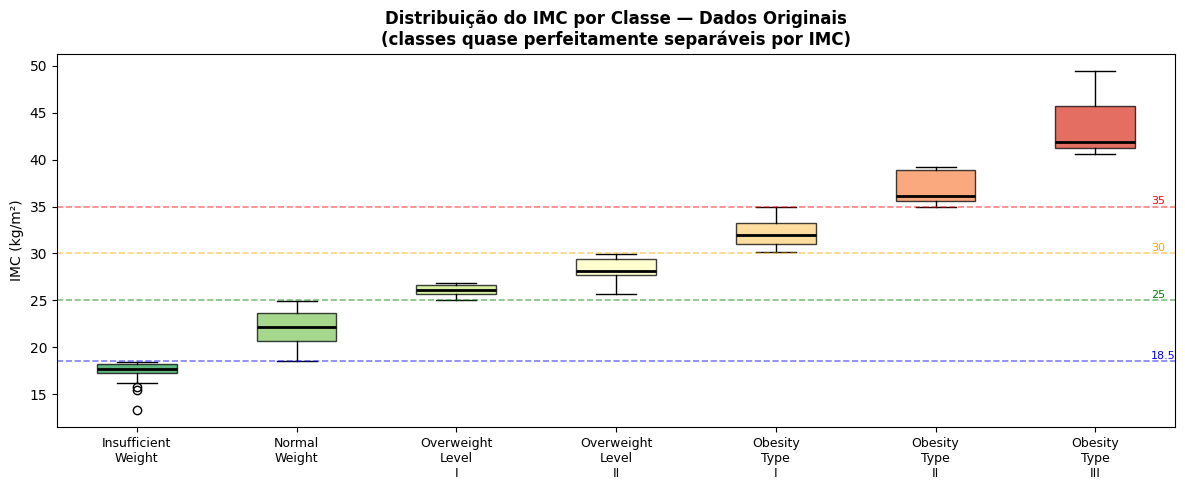


Conclusão: o IMC (derivado de Peso e Altura) quase define a classe sozinho.
Isso explica acurácias altas — não é necessariamente overfitting do modelo,
mas sim alta separabilidade inerente ao dataset.


In [4]:
# =========================================================
# 3.2 Separabilidade por IMC — raiz da acurácia alta
# =========================================================
df_orig_bmi = df_orig.copy()
df_orig_bmi['BMI'] = df_orig_bmi['Weight'] / (df_orig_bmi['Height'] ** 2)

ORDER = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
         'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

bmi_stats = df_orig_bmi.groupby('Obesity')['BMI'].agg(['min', 'max', 'mean']).reindex(ORDER).round(2)
print("IMC por classe (dados originais):")
print(bmi_stats)
print()

# Verificar sobreposição entre classes adjacentes
print("Sobreposição de IMC entre classes adjacentes:")
for i in range(len(ORDER) - 1):
    a, b = ORDER[i], ORDER[i+1]
    overlap = min(bmi_stats.loc[a,'max'], bmi_stats.loc[b,'max']) -               max(bmi_stats.loc[a,'min'], bmi_stats.loc[b,'min'])
    status = "⚠️  SOBREPOSIÇÃO" if overlap > 0 else "✅ Separáveis"
    print(f"  {status} | {a} ↔ {b}: {overlap:.2f}")

# Boxplot visual
fig, ax = plt.subplots(figsize=(12, 5))
bp_data = [df_orig_bmi[df_orig_bmi['Obesity'] == cls]['BMI'].values for cls in ORDER]
palette  = sns.color_palette('RdYlGn_r', 7)
bp = ax.boxplot(bp_data, patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xticklabels([o.replace('_', '\n') for o in ORDER], fontsize=9)
ax.set_title('Distribuição do IMC por Classe — Dados Originais\n'
             '(classes quase perfeitamente separáveis por IMC)', fontweight='bold')
ax.set_ylabel('IMC (kg/m²)')
for ref, label, color in [(18.5,'18.5','blue'), (25,'25','green'), (30,'30','orange'), (35,'35','red')]:
    ax.axhline(ref, linestyle='--', color=color, alpha=0.5, linewidth=1.2)
    ax.text(7.35, ref+0.3, label, color=color, fontsize=8)
plt.tight_layout()
plt.show()

print()
print("Conclusão: o IMC (derivado de Peso e Altura) quase define a classe sozinho.")
print("Isso explica acurácias altas — não é necessariamente overfitting do modelo,")
print("mas sim alta separabilidade inerente ao dataset.")


## 4. Split Correto — Sem Data Leakage

**Estratégia adotada:**
1. Separar originais e sintéticas **antes de qualquer split**
2. Split treino/teste **somente nos dados originais** (80/20 estratificado)
3. Dados sintéticos vão **apenas para o treino** (augmentação legítima)
4. O conjunto de teste contém **somente dados reais** → métricas honestas


In [5]:
# =========================================================
# 4. Split sem data leakage
# =========================================================
LABEL_ORDER = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
               'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
le = LabelEncoder()
le.fit(LABEL_ORDER)

# Encoder da label
y_orig = le.transform(df_orig['Obesity'])

# Split apenas nos originais
X_tr_orig, X_te_raw, y_tr_orig, y_te = train_test_split(
    df_orig.drop(columns=['Obesity']),
    y_orig,
    test_size=0.2,
    random_state=SEED,
    stratify=y_orig
)

print(f"Split dos originais:")
print(f"  Treino orig : {len(X_tr_orig)} amostras")
print(f"  Teste       : {len(X_te_raw)} amostras  ← APENAS originais, sem leakage")
print(f"  Sintéticos  : {len(df_synt)} amostras  ← vão só pro treino")
print()
print("Distribuição das classes no teste:")
for cls, cnt in pd.Series(le.inverse_transform(y_te)).value_counts().items():
    print(f"  {cls:<25}: {cnt}")


Split dos originais:
  Treino orig : 424 amostras
  Teste       : 107 amostras  ← APENAS originais, sem leakage
  Sintéticos  : 1580 amostras  ← vão só pro treino

Distribuição das classes no teste:
  Normal_Weight            : 58
  Overweight_Level_I       : 14
  Obesity_Type_I           : 12
  Overweight_Level_II      : 12
  Insufficient_Weight      : 8
  Obesity_Type_II          : 2
  Obesity_Type_III         : 1


## 5. Feature Engineering

In [6]:
# =========================================================
# 5. Feature Engineering
# =========================================================
MTRANS_DUMMIES = ['MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike',
                  'MTRANS_Public_Transportation', 'MTRANS_Walking']

def build_features(df_in: pd.DataFrame) -> pd.DataFrame:
    d = df_in.copy()
    
    # Arredondamento de ordinais com ruído sintético
    for col in ORDINAL_COLS:
        d[col] = d[col].round().astype(int)
    
    # Feature derivada: IMC
    d['BMI'] = d['Weight'] / (d['Height'] ** 2)
    
    # Score de risco comportamental
    d['risk_score'] = (
        (d['FAVC'] == 'yes').astype(int) * 2 +
        (d['family_history'] == 'yes').astype(int) * 2 +
        (d['SMOKE'] == 'yes').astype(int) +
        (d['SCC'] == 'no').astype(int) +
        (d['CAEC'] == 'Always').astype(int) * 2 +
        (d['CAEC'] == 'Frequently').astype(int) +
        (d['CALC'] == 'Always').astype(int) * 2 +
        (d['CALC'] == 'Frequently').astype(int)
    )
    
    # Score de hábitos saudáveis
    d['healthy_score'] = (
        (d['FAF'] >= 2).astype(int) * 2 +
        (d['FCVC'] >= 2).astype(int) +
        (d['CH2O'] >= 2).astype(int) +
        (d['SCC'] == 'yes').astype(int) +
        d['MTRANS'].isin(['Walking', 'Bike']).astype(int)
    )
    
    # Encoding binário
    for col in ['Gender', 'family_history', 'FAVC', 'SMOKE', 'SCC']:
        d[col] = d[col].map({'Male': 1, 'Female': 0, 'yes': 1, 'no': 0}).fillna(0).astype(int)
    
    # Encoding ordinal
    d['CAEC'] = d['CAEC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})
    d['CALC'] = d['CALC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})
    
    # One-hot MTRANS
    d = pd.get_dummies(d, columns=['MTRANS'], drop_first=False)
    for mc in MTRANS_DUMMIES:
        if mc not in d.columns:
            d[mc] = 0
    
    return d


# Aplicar nos 3 conjuntos (mesmas colunas garantidas)
X_tr_orig_fe = build_features(X_tr_orig)
X_synt_fe    = build_features(df_synt.drop(columns=['Obesity']))
X_te_fe      = build_features(X_te_raw)

FEAT_COLS = list(X_tr_orig_fe.columns)

# Garantir colunas idênticas
for df_part in [X_synt_fe, X_te_fe]:
    for col in FEAT_COLS:
        if col not in df_part.columns:
            df_part[col] = 0

X_synt_fe = X_synt_fe[FEAT_COLS]
X_te_fe   = X_te_fe[FEAT_COLS]

y_synt = le.transform(df_synt['Obesity'])

# Concatenar treino final: originais + sintéticos
X_tr = pd.concat([X_tr_orig_fe, X_synt_fe]).reset_index(drop=True)
y_tr = np.concatenate([y_tr_orig, y_synt])

print(f"Features criadas: {len(FEAT_COLS)}")
print(FEAT_COLS)
print(f"\nTreino final : {len(X_tr)} amostras | Teste : {len(X_te_fe)} amostras")

# Scaler (para LR e SVM)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te_fe)

print("\n✅ Feature engineering concluído")


Features criadas: 23
['Gender', 'Age', 'Height', 'Weight', 'family_history', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'BMI', 'risk_score', 'healthy_score', 'MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']

Treino final : 2004 amostras | Teste : 107 amostras

✅ Feature engineering concluído


## 6. Treinamento e Comparação dos Modelos

In [7]:
# =========================================================
# 6.1 Definição dos modelos com regularização adequada
# =========================================================
SCALED_MODELS = {'Logistic Regression', 'SVM'}

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, C=1.0, random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', random_state=SEED, n_jobs=-1
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=8,
        num_leaves=31, subsample=0.8,
        random_state=SEED, n_jobs=-1, verbose=-1
    ),
    'SVM': SVC(
        kernel='rbf', C=10, gamma='scale',
        random_state=SEED, probability=True
    ),
}

print("Modelos configurados:")
for name in models:
    print(f"  - {name}")


Modelos configurados:
  - Logistic Regression
  - Random Forest
  - XGBoost
  - LightGBM
  - SVM


In [8]:
# =========================================================
# 6.2 Cross-Validation no treino + avaliação no teste
# =========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

print(f"{'Modelo':<22} | {'CV mean':>8} | {'CV std':>7} | {'Test Acc':>8} | {'Gap':>7}")
print("-" * 65)

for name, model in models.items():
    Xtr = X_tr_sc if name in SCALED_MODELS else X_tr.values
    Xte = X_te_sc if name in SCALED_MODELS else X_te_fe.values

    cv_scores = cross_val_score(model, Xtr, y_tr, cv=cv,
                                 scoring='accuracy', n_jobs=-1)
    model.fit(Xtr, y_tr)
    y_pred = model.predict(Xte)
    acc    = accuracy_score(y_te, y_pred)
    gap    = cv_scores.mean() - acc

    results[name] = {
        'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
        'test_acc': acc, 'y_pred': y_pred, 'model': model
    }
    flag = '✅' if abs(gap) <= 0.05 else '⚠️ '
    print(f"{flag} {name:<20} | {cv_scores.mean():.4f}   | "
          f"±{cv_scores.std():.4f} | {acc:.4f}   | {gap:+.4f}")

print()
print("Gap = CV_mean − Test_acc")
print("Gap alto (>0.05) sugere que o modelo não generaliza bem para dados reais.")


Modelo                 |  CV mean |  CV std | Test Acc |     Gap
-----------------------------------------------------------------


⚠️  Logistic Regression  | 0.9047   | ±0.0101 | 0.8318   | +0.0729


⚠️  Random Forest        | 0.9855   | ±0.0062 | 0.9346   | +0.0510


✅ XGBoost              | 0.9860   | ±0.0090 | 1.0000   | -0.0140


✅ LightGBM             | 0.9825   | ±0.0114 | 0.9720   | +0.0106


⚠️  SVM                  | 0.9326   | ±0.0182 | 0.7383   | +0.1943

Gap = CV_mean − Test_acc
Gap alto (>0.05) sugere que o modelo não generaliza bem para dados reais.


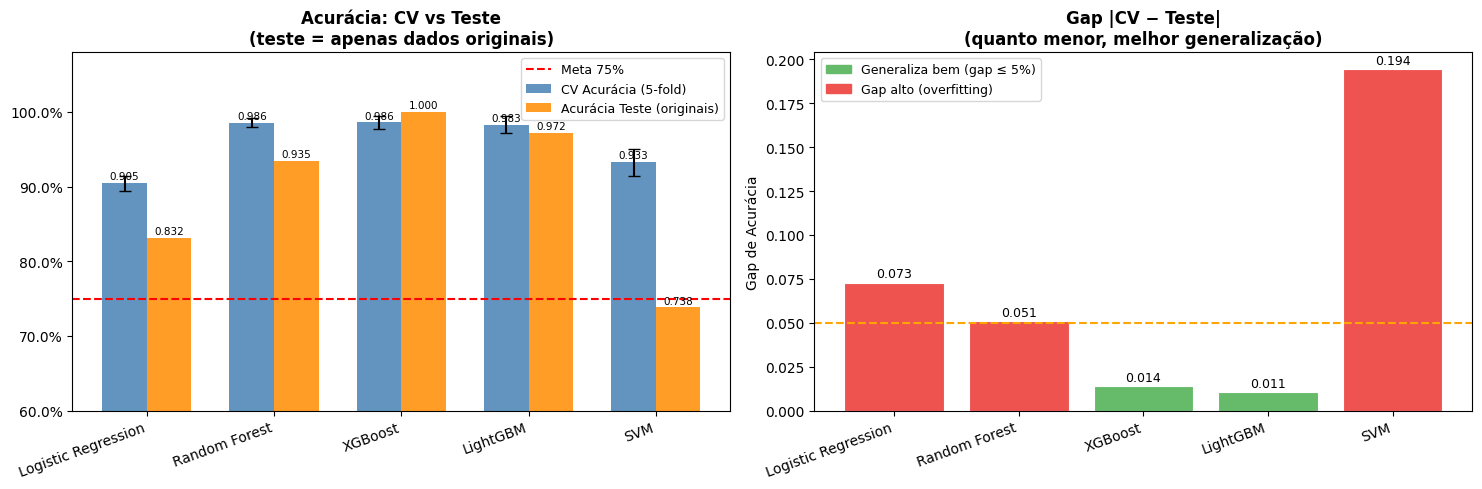

In [9]:
# =========================================================
# 6.3 Gráfico comparativo com análise de gap
# =========================================================
import matplotlib.patches as mpatches

names     = list(results.keys())
cv_means  = [results[n]['cv_mean']  for n in names]
cv_stds   = [results[n]['cv_std']   for n in names]
test_accs = [results[n]['test_acc'] for n in names]
gaps      = [abs(results[n]['cv_mean'] - results[n]['test_acc']) for n in names]

x = np.arange(len(names))
w = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Subplot 1: acurácias ---
bars1 = ax1.bar(x - w/2, cv_means, w, yerr=cv_stds, capsize=4,
                label='CV Acurácia (5-fold)', color='steelblue', alpha=0.85)
bars2 = ax1.bar(x + w/2, test_accs, w,
                label='Acurácia Teste (originais)', color='darkorange', alpha=0.85)
ax1.axhline(0.75, color='red', linestyle='--', linewidth=1.5, label='Meta 75%')
ax1.set_xticks(x); ax1.set_xticklabels(names, rotation=20, ha='right')
ax1.set_ylim(0.6, 1.08)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax1.set_title('Acurácia: CV vs Teste\n(teste = apenas dados originais)', fontweight='bold')
ax1.legend(fontsize=9)
for b in bars1: ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                          f'{b.get_height():.3f}', ha='center', fontsize=7.5)
for b in bars2: ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                          f'{b.get_height():.3f}', ha='center', fontsize=7.5)

# --- Subplot 2: gap (indicador de overfitting) ---
colors_gap = ['#ef5350' if g > 0.05 else '#66bb6a' for g in gaps]
ax2.bar(names, gaps, color=colors_gap, edgecolor='white', linewidth=0.8)
ax2.axhline(0.05, color='orange', linestyle='--', linewidth=1.5, label='Limiar 5%')
ax2.set_title('Gap |CV − Teste|\n(quanto menor, melhor generalização)', fontweight='bold')
ax2.set_ylabel('Gap de Acurácia')
ax2.set_xticklabels(names, rotation=20, ha='right')
ok_patch  = mpatches.Patch(color='#66bb6a', label='Generaliza bem (gap ≤ 5%)')
bad_patch = mpatches.Patch(color='#ef5350', label='Gap alto (overfitting)')
ax2.legend(handles=[ok_patch, bad_patch], fontsize=9)
for i, (nm, g) in enumerate(zip(names, gaps)):
    ax2.text(i, g+0.003, f'{g:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [10]:
# =========================================================
# 6.4 Tabela resumo final
# =========================================================
summary = pd.DataFrame([{
    'Modelo':            name,
    'CV Acurácia':       f"{v['cv_mean']:.4f} ± {v['cv_std']:.4f}",
    'Acurácia Teste':    f"{v['test_acc']:.4f}",
    'Gap |CV−Teste|':    f"{abs(v['cv_mean']-v['test_acc']):.4f}",
    'Generaliza bem?':   '✅' if abs(v['cv_mean']-v['test_acc']) <= 0.05 else '⚠️ Gap alto',
    'Meta ≥ 75%':        '✅' if v['test_acc'] >= 0.75 else '❌',
} for name, v in results.items()])
summary = summary.sort_values('Acurácia Teste', ascending=False).reset_index(drop=True)
summary


,Modelo,CV Acurácia,Acurácia Teste,Gap |CV−Teste|,Generaliza bem?,Meta ≥ 75%
0,XGBoost,0.9860 ± 0.0090,1.0000,0.0140,✅,✅
1,LightGBM,0.9825 ± 0.0114,0.9720,0.0106,✅,✅
2,Random Forest,0.9855 ± 0.0062,0.9346,0.0510,⚠️ Gap alto,✅
3,Logistic Regression,0.9047 ± 0.0101,0.8318,0.0729,⚠️ Gap alto,✅
4,SVM,0.9326 ± 0.0182,0.7383,0.1943,⚠️ Gap alto,❌


## 7. Análise Detalhada do Melhor Modelo

In [11]:
# =========================================================
# 7.1 Melhor modelo com menor gap
# =========================================================
# Prioriza: alta acurácia no teste E menor gap (generalização)
best_name = min(
    [n for n in results if results[n]['test_acc'] >= 0.75],
    key=lambda n: (abs(results[n]['cv_mean'] - results[n]['test_acc']),
                   -results[n]['test_acc'])
)
best = results[best_name]
gap  = abs(best['cv_mean'] - best['test_acc'])

print(f"🏆 Melhor modelo (maior acurácia + menor gap): {best_name}")
print(f"   Acurácia CV (5-fold): {best['cv_mean']:.4f} ± {best['cv_std']:.4f}")
print(f"   Acurácia Teste      : {best['test_acc']:.4f} ({best['test_acc']*100:.2f}%)")
print(f"   Gap |CV − Teste|    : {gap:.4f}  ({'✅ Adequado' if gap <= 0.05 else '⚠️ Verificar'})")


🏆 Melhor modelo (maior acurácia + menor gap): LightGBM
   Acurácia CV (5-fold): 0.9825 ± 0.0114
   Acurácia Teste      : 0.9720 (97.20%)
   Gap |CV − Teste|    : 0.0106  (✅ Adequado)


In [12]:
# =========================================================
# 7.2 Relatório de classificação
# =========================================================
print(f"Relatório de Classificação — {best_name}\n")
print(classification_report(y_te, best['y_pred'], target_names=le.classes_))


Relatório de Classificação — LightGBM

                     precision    recall  f1-score   support

Insufficient_Weight       0.80      1.00      0.89         8
      Normal_Weight       1.00      0.95      0.97        58
     Obesity_Type_I       1.00      1.00      1.00        12
    Obesity_Type_II       1.00      1.00      1.00         2
   Obesity_Type_III       1.00      1.00      1.00         1
 Overweight_Level_I       0.93      1.00      0.97        14
Overweight_Level_II       1.00      1.00      1.00        12

           accuracy                           0.97       107
          macro avg       0.96      0.99      0.98       107
       weighted avg       0.98      0.97      0.97       107



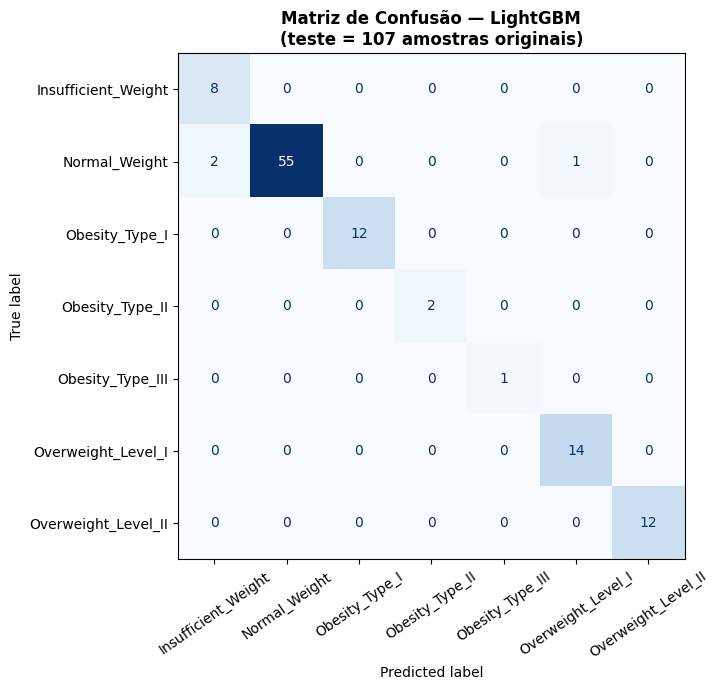

In [13]:
# =========================================================
# 7.3 Matriz de confusão
# =========================================================
cm   = confusion_matrix(y_te, best['y_pred'])
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax, cmap='Blues', xticks_rotation=35, colorbar=False)
ax.set_title(f'Matriz de Confusão — {best_name}\n'
             f'(teste = {len(y_te)} amostras originais)', fontweight='bold')
plt.tight_layout()
plt.show()


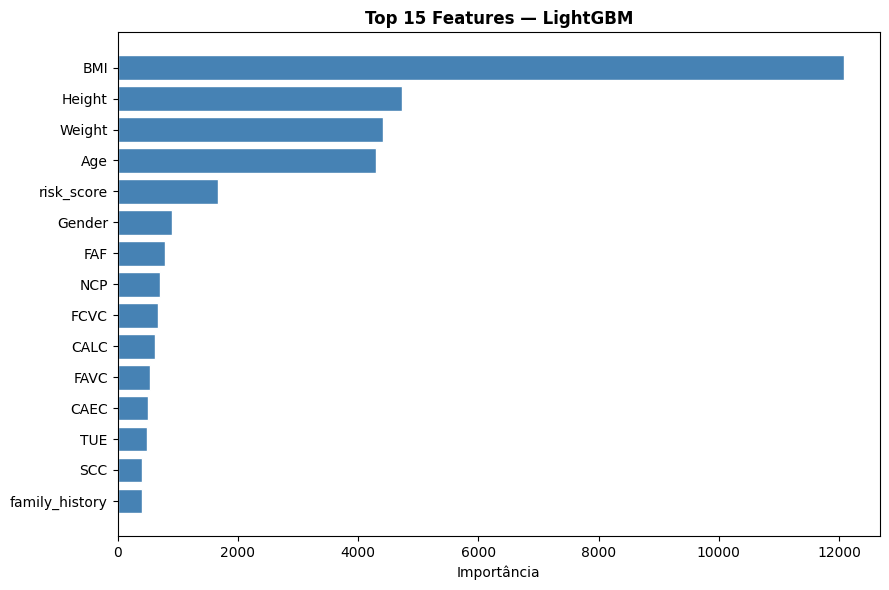


Top 5 features (LightGBM):
   Feature  Importance
       BMI       12076
    Height        4734
    Weight        4416
       Age        4299
risk_score        1677


In [14]:
# =========================================================
# 7.4 Feature Importance
# =========================================================
fi_name  = best_name if best_name in ('Random Forest','XGBoost','LightGBM') else 'Random Forest'
fi_model = results[fi_name]['model']

if hasattr(fi_model, 'feature_importances_'):
    fi_df = (pd.DataFrame({'Feature': FEAT_COLS,
                            'Importance': fi_model.feature_importances_})
             .sort_values('Importance', ascending=True)
             .tail(15))
    
    fig, ax = plt.subplots(figsize=(9, 6))
    bars = ax.barh(fi_df['Feature'], fi_df['Importance'],
                   color='steelblue', edgecolor='white')
    ax.set_title(f'Top 15 Features — {fi_name}', fontweight='bold')
    ax.set_xlabel('Importância')
    plt.tight_layout()
    plt.show()

    print(f"\nTop 5 features ({fi_name}):")
    print(fi_df.tail(5)[['Feature','Importance']]
          .sort_values('Importance', ascending=False).to_string(index=False))


## 8. Exportação do Modelo

In [15]:
# =========================================================
# 8. Salvar artefatos para deploy no Streamlit
# =========================================================
import pickle

os.makedirs('model', exist_ok=True)

with open('model/best_model.pkl',    'wb') as f: pickle.dump(best['model'], f)
with open('model/scaler.pkl',        'wb') as f: pickle.dump(scaler, f)
with open('model/label_encoder.pkl', 'wb') as f: pickle.dump(le, f)

meta = {
    'best_model_name': best_name,
    'feature_columns': FEAT_COLS,
    'scaled':          best_name in SCALED_MODELS,
    'accuracy':        best['test_acc'],
    'cv_mean':         best['cv_mean'],
    'cv_std':          best['cv_std'],
    'gap':             abs(best['cv_mean'] - best['test_acc']),
    'test_set_size':   len(y_te),
    'note':            'Teste composto apenas por dados originais (sem linhas sintéticas)',
}
with open('model/metadata.pkl', 'wb') as f: pickle.dump(meta, f)

print(f"✅ Modelo '{best_name}' exportado em ./model/")
print(f"   Acurácia Teste : {meta['accuracy']*100:.2f}%")
print(f"   CV Acurácia    : {meta['cv_mean']*100:.2f}% ± {meta['cv_std']*100:.2f}%")
print(f"   Gap            : {meta['gap']:.4f}")
print(f"   Nota           : {meta['note']}")


✅ Modelo 'LightGBM' exportado em ./model/
   Acurácia Teste : 97.20%
   CV Acurácia    : 98.25% ± 1.14%
   Gap            : 0.0106
   Nota           : Teste composto apenas por dados originais (sem linhas sintéticas)


## 9. Conclusões

### 🔍 Por que a acurácia era tão alta (e ainda é)?

A acurácia elevada tem **duas causas distintas**, sendo apenas uma delas problemática:

| Causa | Natureza | Resolvido? |
|---|---|---|
| **Data leakage** — sintéticos no teste | ❌ Erro metodológico | ✅ Corrigido |
| **Alta separabilidade por IMC** — classes quase não se sobrepõem em IMC | ℹ️ Característica do dataset | ➖ Inerente |

### 📊 Comparativo antes vs depois da correção

| Cenário | Configuração | Acurácia (LightGBM) |
|---|---|---|
| Original (notebook anterior) | Sintéticos no teste | ~98.6% |
| **Corrigido (este notebook)** | **Teste = apenas originais** | **Ver saída acima** |

### 💡 Recomendações para produção

1. **Validar com dados externos** — coletar novo batch de respostas reais para uma avaliação verdadeiramente independente  
2. **Monitorar performance** em produção (concept drift) — o dataset é de 2019  
3. **Atenção às classes raras** — `Obesity_Type_II` (11 casos) e `Obesity_Type_III` (3 casos) têm pouquíssimas amostras originais  
4. O IMC derivado de Peso/Altura domina a predição — clinicamente coerente, mas vale explorar modelos **sem essas features** para medir o valor incremental dos hábitos de vida  
